In [447]:
import time
import pickle
import math
import random
from tqdm import tqdm
from collections import defaultdict
from itertools import product

In [448]:
%load_ext autoreload
%autoreload 2
import os
import sys
module_path = os.path.abspath(os.path.join('..')) 
sys.path.insert(0, module_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [449]:
from hex_plot import plot_problem
from hex_star import PathfindingProblem, f, time_to_goal, best_first_search, q_learning, q_key, combo_h

In [450]:
maps_dir = "maps"
q_values_dir = "q"

In [451]:
def save_layout(layout, filename):
    with open(filename, 'wb') as file:
        pickle.dump(layout, file)

def load_layout(filename):
    with open(filename, 'rb') as file:
        return pickle.load(file)

In [452]:
def get_solution_path(solution, nodes=False):
    if solution is not None:
        current_node = solution
        solution_path = []
        while current_node.parent is not None:
            loc, _ = current_node.state
            if nodes:
                solution_path.append(current_node)
            else:
                solution_path.append(loc)
            current_node = current_node.parent
        
        return list(reversed(solution_path))
    return None

In [456]:
MAX_ACCELERATION = 5
MAX_DECELERATION = 10
MAX_LAT_ACCELERATION = 2

# q learning parameters
LEARNING_RATE = 0.01
DISCOUNT_FACTOR = 0.95

map_file = 'r25h1.00.pkl'

### Set up 1 test episode

In [458]:

# Load the map
hex_layout = load_layout(f'{maps_dir}/{map_file}')

# Get the initial state
initial_state = (
    hex_layout['agent'],
    hex_layout['velocity']
)

# Initialize search parameters
params = {
    'hex_map': hex_layout['hex_map'],
    'obstacle_map': hex_layout['obstacle_map'],
    'goal_loc': hex_layout['goal'],
    'hex_radius': hex_layout['hex_radius'],
    'hex_size': hex_layout['hex_size'],
    'acceleration_max': MAX_ACCELERATION,
    'deceleration_max': MAX_DECELERATION,
    'lat_acceleration_max': MAX_LAT_ACCELERATION,
    'q_learning_rate': LEARNING_RATE,
    'q_discount_factor': DISCOUNT_FACTOR
}
h = q_learning

params['agent_size_r'] = 1



problem = PathfindingProblem(initial_state, **params)

In [459]:
solution = best_first_search(problem, f, h, max_solutions=1)
q_values = problem.q_values

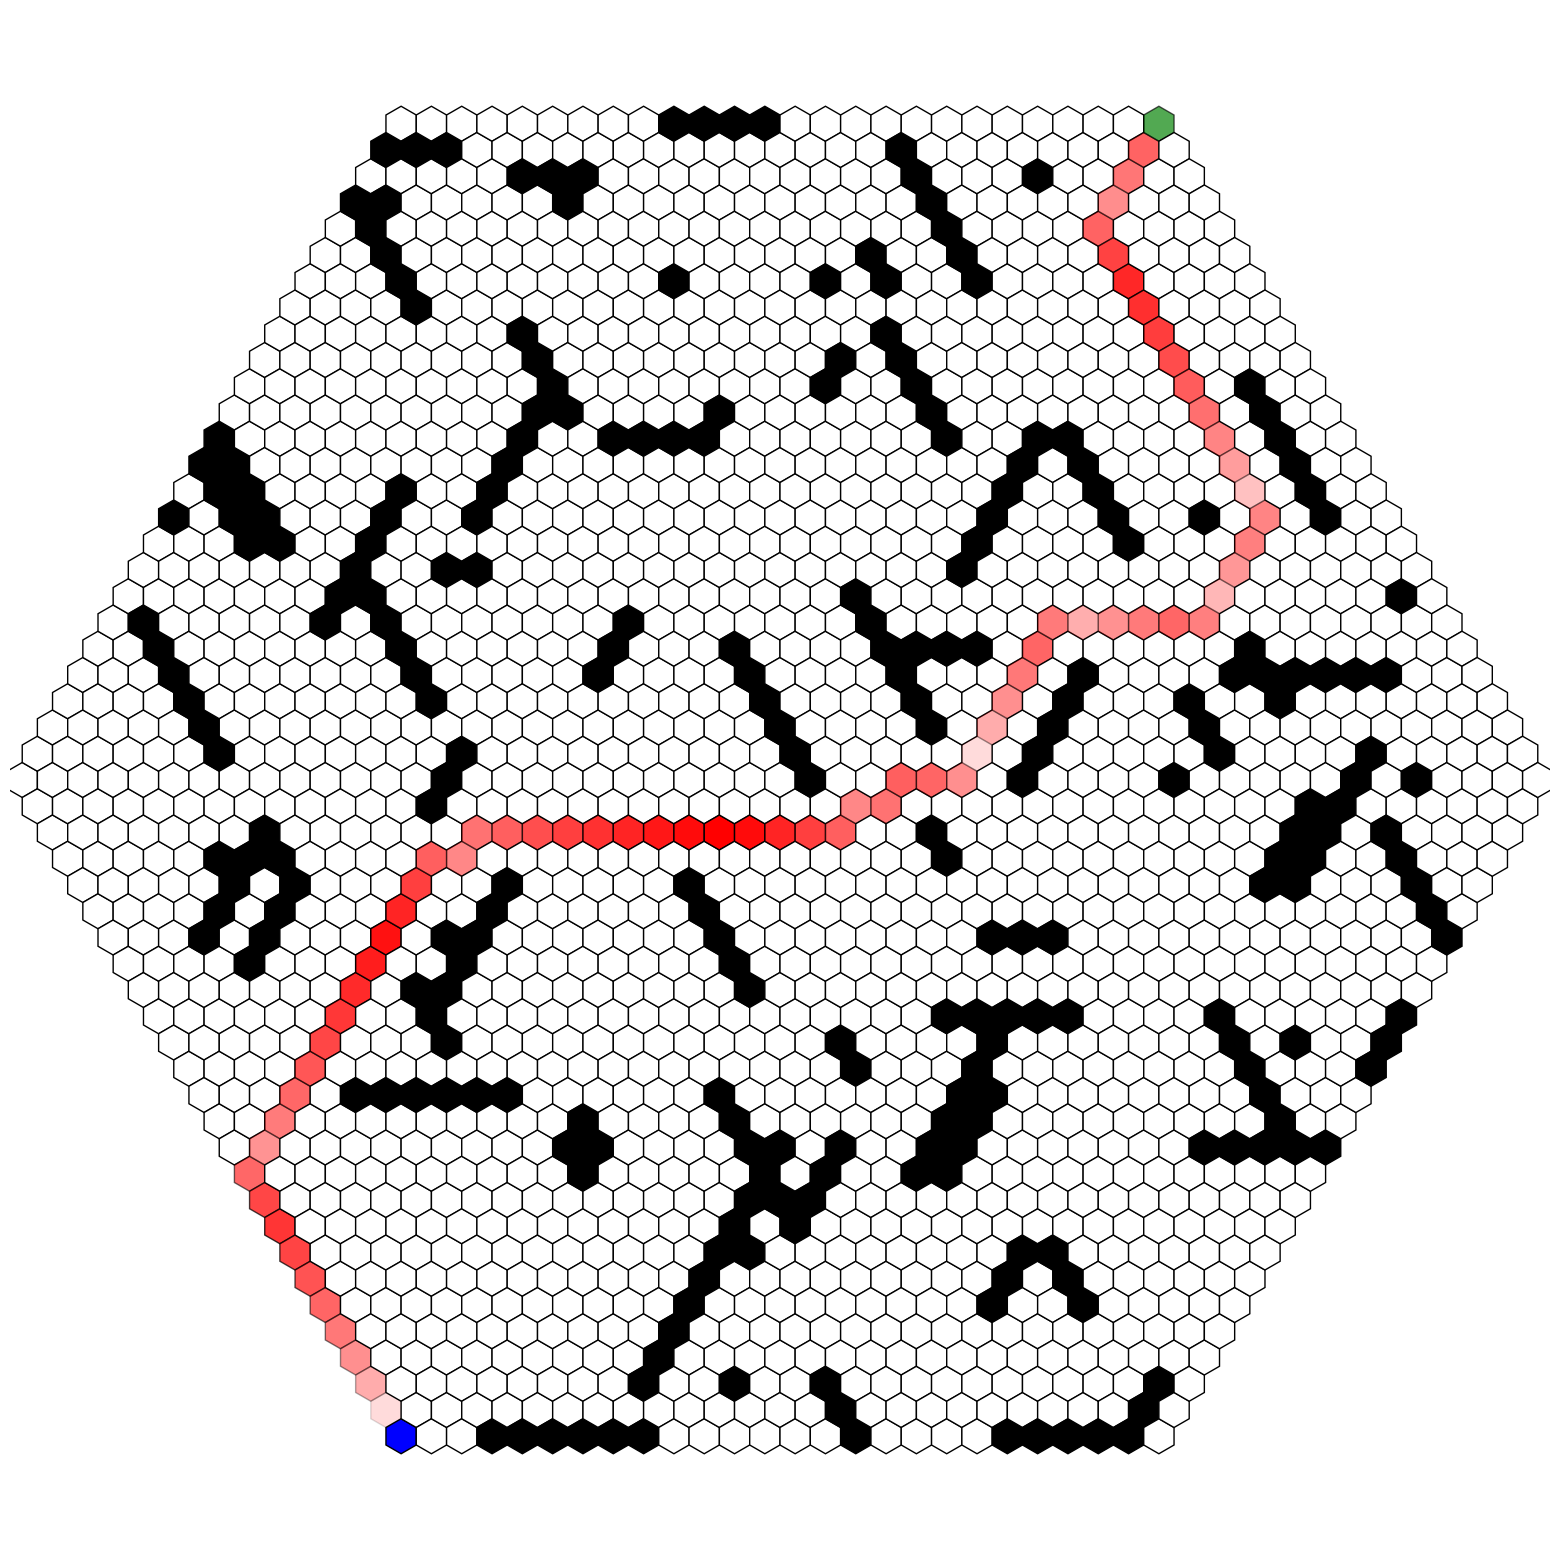

In [463]:
plot_problem(problem, solution[0])

In [460]:
# Construct the solution path and show the q values after one iteration
solution_path = get_solution_path(solution[0], nodes=True)
[q_values[q_key(s)] for s in solution_path]

[0.008487209624748837,
 0.005771572717286345,
 0.004727656306415329,
 0.004110624904367498,
 0.0036882823525995175,
 0.0033751264144928172,
 0.0031311817439982625,
 0.002983846080629572,
 0.003397885572457658,
 0.001971015972117062,
 0.004849437063478751,
 0.00418895268104922,
 0.0037442328248675468,
 0.0034177083050509712,
 0.0031645344522854874,
 0.002960675308642651,
 0.0027918978263801403,
 0.002649845036955151,
 0.002602335176182597,
 0.0028229498169161644,
 0.00283529306502606,
 0.0012714960190880035,
 0.004507117963396535,
 0.003964538518605688,
 0.0035821399693694734,
 0.003293423109521098,
 0.00306526791559842,
 0.0028789951215431576,
 0.0027231370381975216,
 0.002590202936540648,
 0.0024751396458648958,
 0.0023826789812080675,
 0.00259435393670487,
 0.0025811475203996992,
 0.002618931065704843,
 0.0009085343246175049,
 0.004507103419785751,
 0.003963007612207333,
 0.0034209919274373795,
 0.0043647366831909605,
 0.0022104370069654044,
 0.008487209625427726,
 0.0057715727887482

In [461]:
MAX_ACCELERATION = 5
MAX_DECELERATION = 10
MAX_LAT_ACCELERATION = 2

# q learning parameters
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 1

COLLISION_RADIUS = 1

map_file = 'r25h1.00.pkl'

# Load the map
hex_layout = load_layout(f'{maps_dir}/{map_file}')

# Get the initial state
initial_state = (
    hex_layout['agent'],
    hex_layout['velocity']
)

# Initialize search parameters
params = {
    'hex_map': hex_layout['hex_map'],
    'obstacle_map': hex_layout['obstacle_map'],
    'goal_loc': hex_layout['goal'],
    'hex_radius': hex_layout['hex_radius'],
    'hex_size': hex_layout['hex_size'],
    'agent_size_r': COLLISION_RADIUS,
    'acceleration_max': MAX_ACCELERATION,
    'deceleration_max': MAX_DECELERATION,
    'lat_acceleration_max': MAX_LAT_ACCELERATION,
    'q_learning_rate': LEARNING_RATE,
    'q_discount_factor': DISCOUNT_FACTOR
}
h = q_learning
    

In [438]:
NUM_ITERATIONS =50
q_values = None
randomize_initial_state = False
randomize_goal_state = False

problem = PathfindingProblem(initial_state, q_values=q_values, **params)


In [439]:
# Get a list of hexes without an obstacle
free_hexes =[p for p in params['hex_map'] if p not in params['obstacle_map']]

In [440]:
for i in tqdm(range(NUM_ITERATIONS)):
    # Preselect a start and goal loc without replacement
    start_options = random.sample(free_hexes, k=2)

    if randomize_initial_state:
        problem.initial_state = (
            start_options[0],
            (0, None)
        )
        
    if randomize_goal_state:
        problem.goal_loc = start_options[1]
        
    solution = best_first_search(problem, f, h, max_solutions=100)

100%|██████████| 50/50 [06:41<00:00,  8.03s/it]


In [446]:
h = time_to_goal
start = time.time()
solution = best_first_search(problem, f, time_to_goal, max_solutions=1)
print(f'Time: {time.time() - start}')

Time: 7.526018142700195


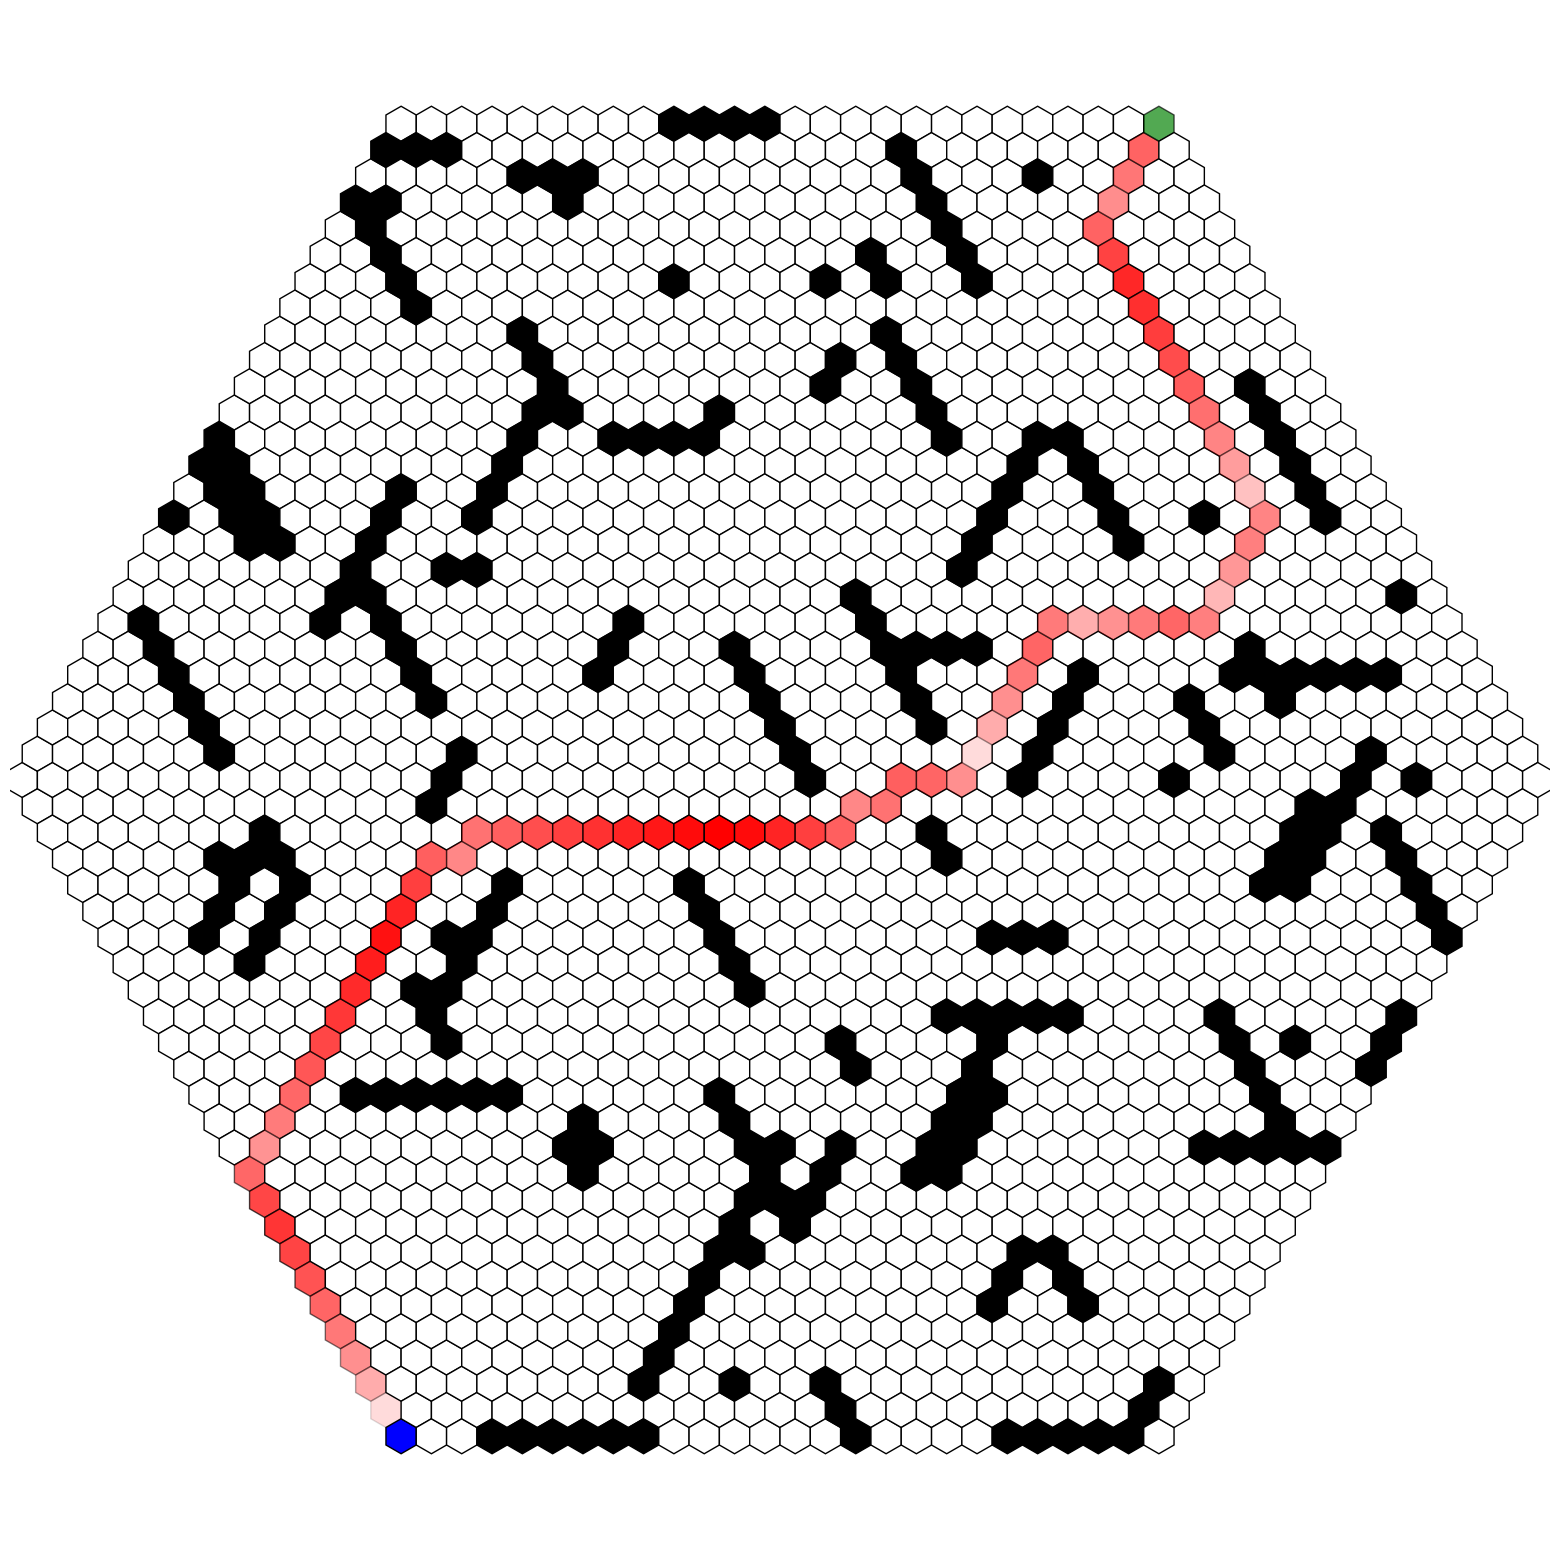

In [442]:
plot_problem(problem, solution[0])

In [443]:
# Construct the solution path and show the q values after one iteration
solution_path = get_solution_path(solution[0], nodes=True)
[problem.q_values[q_key(s)] for s in solution_path]

[27.082616123364858,
 26.239953297627398,
 25.66784628162021,
 25.199533848935577,
 24.79252273898083,
 24.42746151876774,
 24.093511220714998,
 23.783852239353045,
 23.48935791040045,
 23.15213058472362,
 22.960327086430024,
 22.480022707181007,
 22.065277228889553,
 21.69459947923474,
 21.35623310481562,
 21.04291316402004,
 20.749797491852647,
 20.47348539261026,
 20.211485072815595,
 19.954670377727044,
 19.676057211406867,
 19.3949294165576,
 19.273331873006846,
 18.827534624948846,
 18.435280431142097,
 18.080442935045166,
 17.75362141120913,
 17.44888348461976,
 17.162362594794867,
 16.891520287215386,
 16.63466185164866,
 16.39054765046796,
 16.157484524210215,
 15.904694095942437,
 15.654029631858904,
 15.397559016196041,
 15.313712324693835,
 14.866369273681405,
 14.469136979866382,
 14.12357943169432,
 13.679655061446768,
 13.457402308426431,
 12.607313231861271,
 12.031267671707436,
 11.561943766236025,
 11.157475699643125,
 10.822471782078372,
 10.859523374623526,
 10.2758

In [444]:
[time_to_goal(s) for s in solution_path]

[7.93318860357517,
 7.4511726595689876,
 7.172679863240245,
 6.960830256171076,
 6.78574319677802,
 6.634801546985079,
 6.501262916591733,
 6.381022281795026,
 6.5206834709075805,
 6.810659492010677,
 7.126847642217311,
 6.824723741049465,
 6.562260350453421,
 6.32533715576176,
 6.106603750136854,
 5.901653965333175,
 5.707598850906409,
 5.522422130084853,
 5.344650028293333,
 5.399675958186494,
 5.524506042577366,
 5.696343367009094,
 5.955431098515584,
 5.668206155468966,
 5.412715423030439,
 5.178744823910844,
 4.960566324852605,
 4.754583857925516,
 4.558363177868946,
 4.37016475680918,
 4.1886934852696465,
 4.012953564516776,
 3.984591676373589,
 4.150021009499063,
 4.347705594586289,
 4.594916049170668,
 4.820435311624951,
 4.6370345775135,
 4.373489826877974,
 4.417526070688153,
 4.772296654350609,
 5.380603385921097,
 4.796880489720206,
 4.41624388591682,
 4.101789706181971,
 3.8236123083509908,
 3.8613477953914113,
 4.313948013902946,
 4.052655831279509,
 3.8613477953914113,
 

In [445]:
solution[0].path_cost

27.15543330480695